# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [21]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [22]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [23]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [24]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [25]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)
 
label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "class index": list(range(num_classes)),
    "class name": class_names,
    "number of training samples": [np.sum(y_train == i) for i in range(num_classes)]
})

summary_df


X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


,class index,class name,number of training samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [26]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [27]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1398 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1150 - accuracy: 0.9572 - val_loss: 0.2550 - val_accuracy: 0.9164
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0916 - accuracy: 0.9636 - val_loss: 0.1449 - val_accuracy: 0.9422
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0873 - accuracy: 0.9657 - val_loss: 0.2036 - val_accuracy: 0.9259
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0743 - accuracy: 0.9696 - val_loss: 0.1790 - val_accuracy: 0.9388
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0662 - accuracy: 0.9747 - val_loss: 0.1292 - val_accuracy: 0.9483
Epoch 8/40
92/92 [==

### Training Curves


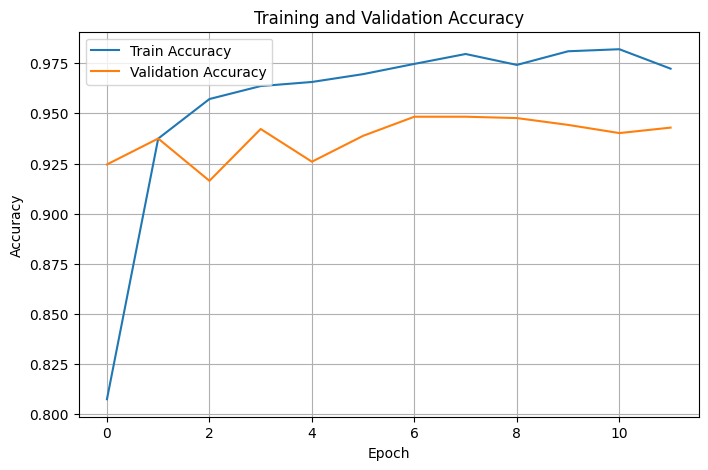

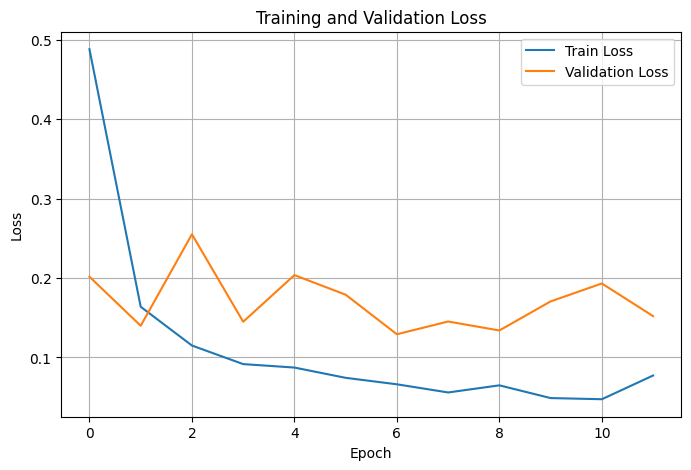

In [28]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 500us/step
Baseline Keras Test Accuracy: 0.9331523583305056

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.96      0.98      0.97       496
  WALKING_UPSTAIRS       0.86      0.97      0.92       471
WALKING_DOWNSTAIRS       0.99      0.83      0.90       420
           SITTING       0.94      0.88      0.91       491
          STANDING       0.88      0.95      0.91       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



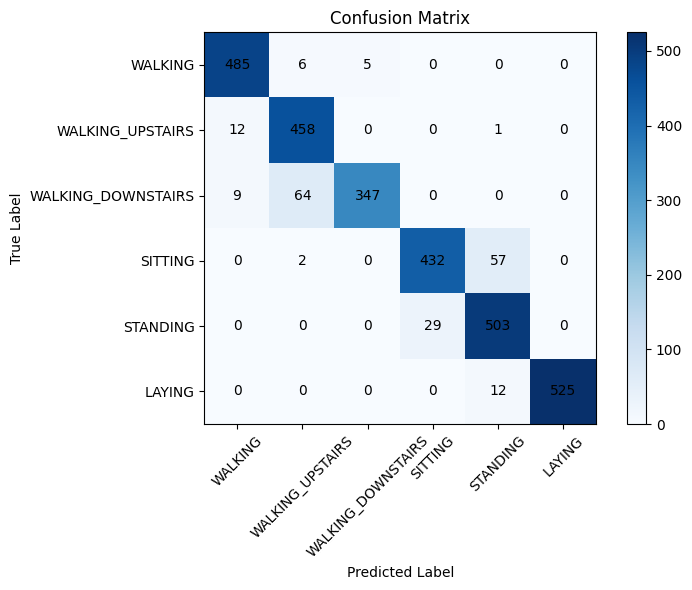

In [29]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print("Baseline Keras Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [30]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"] == np.int8:
            x = x / input_scale + input_zero_point
            x = np.round(x).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = x / input_scale + input_zero_point
            x = np.round(x).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        else:
            output = output.astype(np.float32)

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [31]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# FP32 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
tflite_fp32 = converter.convert()
size_fp32 = save_binary_model(tflite_fp32, "baseline_fp32.tflite")
acc_fp32, pred_fp32 = evaluate_tflite_model(tflite_fp32, X_test, y_test)

# Dynamic Range Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_dynamic = converter.convert()
size_dynamic = save_binary_model(tflite_dynamic, "baseline_dynamic.tflite")
acc_dynamic, pred_dynamic = evaluate_tflite_model(tflite_dynamic, X_test, y_test)

# Float16 Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_float16 = converter.convert()
size_float16 = save_binary_model(tflite_float16, "baseline_float16.tflite")
acc_float16, pred_float16 = evaluate_tflite_model(tflite_float16, X_test, y_test)

# Full Integer Int8 Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_int8 = converter.convert()
size_int8 = save_binary_model(tflite_int8, "baseline_int8.tflite")
acc_int8, pred_int8 = evaluate_tflite_model(tflite_int8, X_test, y_test)

INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpvvk42t05/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpvvk42t05/assets
2026-04-23 09:59:25.997953: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 09:59:25.997962: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 09:59:25.998051: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpvvk42t05
2026-04-23 09:59:25.998509: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 09:59:25.998513: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpvvk42t05
2026-04-23 09:59:25.999625: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 09:59:26.018651: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpxhn5kom9/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpxhn5kom9/assets
2026-04-23 09:59:26.298981: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 09:59:26.298991: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 09:59:26.299099: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpxhn5kom9
2026-04-23 09:59:26.299643: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 09:59:26.299647: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpxhn5kom9
2026-04-23 09:59:26.300787: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 09:59:26.319844: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp58f_bhv3/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp58f_bhv3/assets
2026-04-23 09:59:26.726022: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 09:59:26.726031: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 09:59:26.726127: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp58f_bhv3
2026-04-23 09:59:26.726596: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 09:59:26.726601: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp58f_bhv3
2026-04-23 09:59:26.727823: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 09:59:26.750127: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpbuuxf8hy/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpbuuxf8hy/assets
/Users/ethanjia/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 09:59:27.028991: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 09:59:27.029000: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 09:59:27.029089: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpbuuxf8hy
2026-04-23 09:59:27.029601: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 09:59:27.029606: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1f

## 10. PTQ Comparison: Accuracy and Model Size


In [32]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

ptq_results_df = pd.DataFrame([
    ["Baseline DNN", "FP32 TFLite", acc_fp32, size_fp32],
    ["Baseline DNN", "Dynamic Range TFLite", acc_dynamic, size_dynamic],
    ["Baseline DNN", "Float16 TFLite", acc_float16, size_float16],
    ["Baseline DNN", "Int8 TFLite", acc_int8, size_int8],
], columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"])

ptq_results_df

,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN,FP32 TFLite,0.933152,726.750000
1,Baseline DNN,Dynamic Range TFLite,0.933492,186.140625
2,Baseline DNN,Float16 TFLite,0.933152,365.773438
3,Baseline DNN,Int8 TFLite,0.933831,185.351562


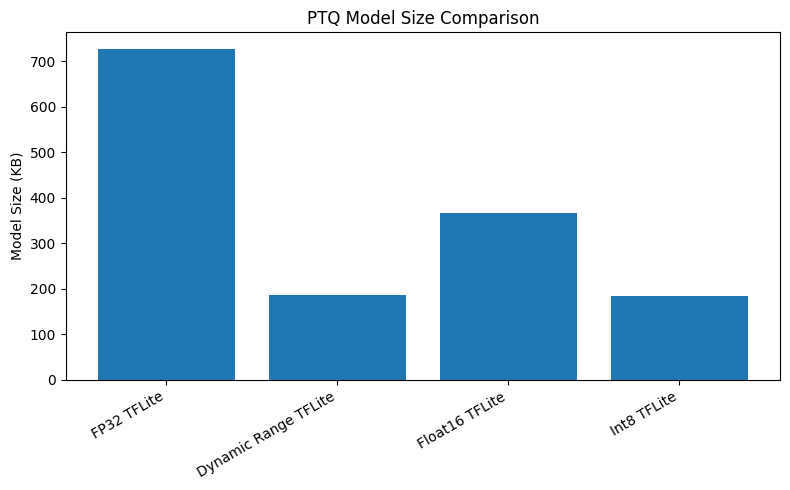

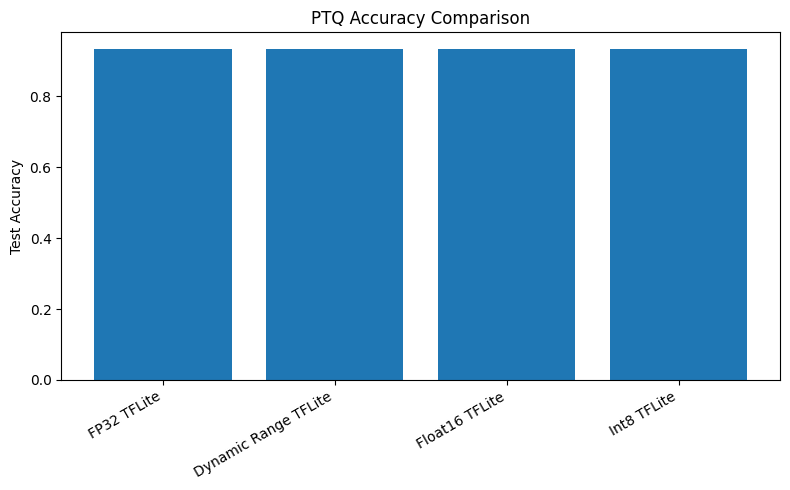

In [33]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

plt.figure(figsize=(8, 5))
plt.bar(ptq_results_df["Format"], ptq_results_df["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("PTQ Model Size Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(ptq_results_df["Format"], ptq_results_df["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("PTQ Accuracy Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


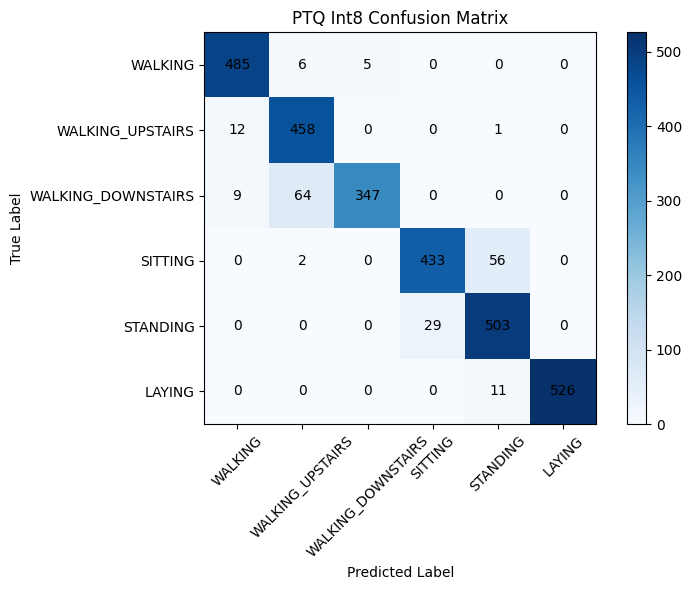

PTQ Int8 Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.96      0.98      0.97       496
  WALKING_UPSTAIRS       0.86      0.97      0.92       471
WALKING_DOWNSTAIRS       0.99      0.83      0.90       420
           SITTING       0.94      0.88      0.91       491
          STANDING       0.88      0.95      0.91       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



In [34]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

cm_int8 = confusion_matrix(y_test, pred_int8)

plt.figure(figsize=(8, 6))
plt.imshow(cm_int8, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(cm_int8.shape[0]):
    for j in range(cm_int8.shape[1]):
        plt.text(j, i, str(cm_int8[i, j]), ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("PTQ Int8 Confusion Matrix")
plt.tight_layout()
plt.show()

print("PTQ Int8 Classification Report:")
print(classification_report(y_test, pred_int8, target_names=class_names))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [35]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

qat_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer_1 (Quantize  (None, 561)               3         
 Layer)                                                          
                                                                 
 quant_dense_4 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_5 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_6 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_7 (QuantizeWra  (None, 6)                

### Fine-Tune the QAT Model


In [36]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0471 - accuracy: 0.9855 - val_loss: 0.1259 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0388 - accuracy: 0.9864 - val_loss: 0.1227 - val_accuracy: 0.9490
Epoch 3/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0374 - accuracy: 0.9866 - val_loss: 0.1341 - val_accuracy: 0.9504
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0344 - accuracy: 0.9876 - val_loss: 0.1262 - val_accuracy: 0.9477
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0333 - accuracy: 0.9879 - val_loss: 0.1626 - val_accuracy: 0.9443
Epoch 6/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0332 - accuracy: 0.9881 - val_loss: 0.1433 - val_accuracy: 0.9497
Epoch 7/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0331 - accuracy: 0.9888 - val_loss: 0.1307 - val_accuracy: 0.9497
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [37]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_prob = qat_model.predict(X_test)
qat_pred = np.argmax(qat_prob, axis=1)

qat_keras_acc = accuracy_score(y_test, qat_pred)
print("QAT Keras Test Accuracy:", qat_keras_acc)

print("\nQAT Keras Classification Report:")
print(classification_report(y_test, qat_pred, target_names=class_names))

93/93 [==============================] - 0s 496us/step
QAT Keras Test Accuracy: 0.9314557176789956

QAT Keras Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.92      0.97      0.95       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.96      0.85      0.90       491
          STANDING       0.84      0.97      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [38]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

qat_int8_tflite = converter.convert()
qat_int8_size = save_binary_model(qat_int8_tflite, "qat_int8.tflite")
qat_int8_acc, qat_int8_pred = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)

print("QAT Int8 TFLite Test Accuracy:", qat_int8_acc)
print("QAT Int8 TFLite Model Size (KB):", qat_int8_size)

INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmplqzs6kj0/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmplqzs6kj0/assets
/Users/ethanjia/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


QAT Int8 TFLite Test Accuracy: 0.9311163895486936
QAT Int8 TFLite Model Size (KB): 185.7734375


2026-04-23 09:59:31.469929: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 09:59:31.469938: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 09:59:31.470032: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmplqzs6kj0
2026-04-23 09:59:31.471217: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 09:59:31.471223: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmplqzs6kj0
2026-04-23 09:59:31.474175: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 09:59:31.506200: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmplqzs6kj0
2026-04-

## 12. PTQ Int8 vs QAT Int8


In [39]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

qat_compare_df = pd.DataFrame([
    ["PTQ Int8", acc_int8, size_int8],
    ["QAT Int8", qat_int8_acc, qat_int8_size]
], columns=["Model", "Test Accuracy", "Model Size (KB)"])

qat_compare_df

,Model,Test Accuracy,Model Size (KB)
0,PTQ Int8,0.933831,185.351562
1,QAT Int8,0.931116,185.773438


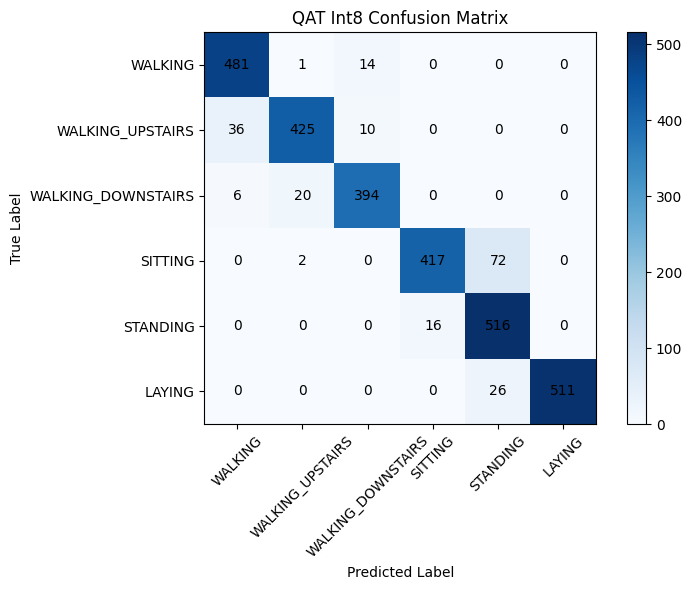

In [40]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

cm_qat_int8 = confusion_matrix(y_test, qat_int8_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm_qat_int8, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(cm_qat_int8.shape[0]):
    for j in range(cm_qat_int8.shape[1]):
        plt.text(j, i, str(cm_qat_int8[i, j]), ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("QAT Int8 Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


1. Int8 quantization (PTQ Int8) gave the smallest model size.
2. PTQ Int8 gave the best accuracy among the TensorFlow Lite models.
3. No. QAT did not improve the final int8 model, since its accuracy was slightly lower than PTQ int8.
4. This dataset is a good fit for TinyML because it is structured, numeric sensor data and can be classified well using a small DNN model with good accuracy.
5. I would choose PTQ Int8, because it offers the best balance of very small model size and highest TFLite accuracy, which is ideal for a resource-constrained device.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
